***
# Homework 6: numpy, scipy and matplotlib

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten.

**Date:** March 8th, 2024
***

In [1]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

## 1.) Warmup: Around the Semicircular Law (3 points, spent $\approx$ 30 minutes)

**The (comparatively) young field of random matrix theory (RMT) concerns the behavior of certain matrices with independent random entries. A landmark result in RMT concerns the behavior of the eigenvalues of a random symmetric matrix with normal entries. Under the proper scaling, the joint distribution of the eigenvalues of such a matrix follows the *Wigner semicircular distribution*, which has density**

$$ f(x) = 
\begin{cases} 
\frac{\sqrt{4 - x^2}}{2\pi} & \text{If}\;-2 \le x \le 2\\
0 & \text{Otherwise}
\end{cases} \quad \quad (1)$$

**That is, a symmetric matrix with random normal entries will have eigenvalues whose histogram looks more and more like a semicircle of radius $2$ as n increases to $\infty$. In particular, define a matrix-valued random variable $Z \in \mathbb{R}^{n \times n}$ by generating $Z_{ij}$ iid normal with mean $0$ and variance $\frac{1}{n}$ for all $1 \le i \le j \le n$, and set $Z_{ji} = Z_{ij}$ for $1 \le j \le i \le n$. Then the matrix $Z \in \mathbb{R}^{n \times n}$ is called a *Wigner matrix*.**

**Define a function `wigner_density` that takes a single number (integer or float) as its input and returns a float as its output, given by the value of the semicircular density evaluated at the input. That is, for a number `x`, `wigner_density(x)` should return $f(x)$, where $f$ is defined above in Equation (1). You do not need to perform any error checking in this function, but note that your function should operate equally well on Python ints/floats and on numpy ints/floats, and you should be able to accomplish this without checking the type of the input. Use the `numpy.sqrt` function for the square root, NOT the Python `math.sqrt` function.**

In [2]:
def wigner_density(x):
    '''
    function to calculate the Wigner semicircle density

    input
    x : int or float
        the value at which to calculate the density

    output
    f(x) : float
           sqrt(4 - x^2) / (2 * pi) if -2 <= x <= 2
           0 otherwise
    '''
    if -2 <= x and x <= 2:
        return np.sqrt(4 - x**2) / (2 * (np.pi))
    else:
        return 0.0

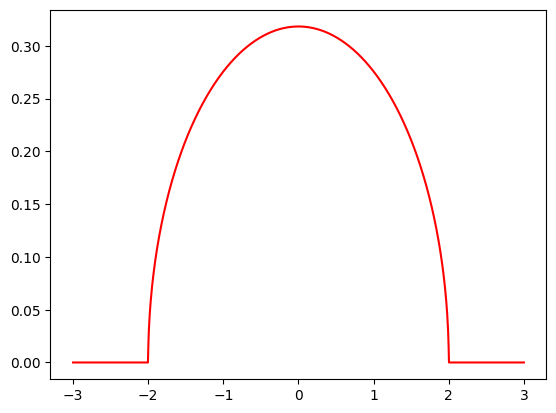

In [3]:
x = np.linspace(-3, 3, 1000) # generates 1000 evenly spaced values from -3 to 3
y = list(map(lambda xi: wigner_density(xi), x)) # calculates the Wigner semicircle density for each value in x

plt.plot(x, y, color = 'red')

**Define a function `generate_wigner` that takes a single positive integer `n` as its argument and returns a random $n$-by-$n$ Wigner matrix. Your function should raise an appropriate error in the event that the input is not a positive integer. The output of your function may be either a `numpy` matrix or simply a `numpy` array, though I would recommend the former, for ease of use in the next sub-problem. You can cast a 2-dimensional `numpy` array a to a matrix by writing `np.matrix(a)`.** 

**Hint: depending on the solution you choose, you may find the `numpy.triu` and `numpy.tril` functions to be useful. A different solution makes use of the `scipy.spatial.distance.squareform` function.**

In [4]:
def generate_wigner(n):
    '''
    function to generate a Wigner matrix of size n-by-n

    n : int
        the size of the Wigner matrix

    output
    Z : 2-dimensional numpy.ndarray
        the Wigner matrix of size n-by-n
    '''

    if not isinstance(n, (int, )):
        raise TypeError(f'n = {n} must be of type int.') # raises error when n is not of type int.
    if n <= 0:
        raise ValueError(f'n = {n} must be a positive integer.') # raises error when n is not a positive integer.
    
    Z_upper = np.triu(np.matrix(np.random.normal(0, 1/np.sqrt(n), (n, n)))) # generates a n-by-n matrix of random normal values

    Z = Z_upper + Z_upper.T - np.diag(Z_upper.diagonal()) # generates the Wigner matrix by adding the upper triangular matrix to its transpose and subtracting the diagonal
    
    return Z

example_wigner = generate_wigner(5)
example_wigner

array([[-0.29352569, -0.67958392,  1.17350321,  0.08059504,  0.68455999],
       [-0.67958392, -0.19153872,  0.4252699 ,  0.33374361,  0.47547827],
       [ 1.17350321,  0.4252699 , -0.42780643, -0.0425688 , -0.40445979],
       [ 0.08059504,  0.33374361, -0.0425688 , -0.40652403, -0.1270375 ],
       [ 0.68455999,  0.47547827, -0.40445979, -0.1270375 ,  0.1802488 ]])

**The RMT result referenced above states that the joint distribution of the eigenvalues of a random Wigner matrix converges to the semicircular law. Write a function `get_spectrum` that takes a numpy matrix or 2-dimensional numpy array and returns a numpy array of its eigenvalues in *non-decreasing* order. You do not need to perform any error checking for this function.**

In [5]:
def get_spectrum(Z):
    '''
    function to calculate the eigenvalues of Wigner matrix

    input
    Z : numpy.ndarray
        the Wigner matrix of size n-by-n

    output
    eigenvalues : numpy.ndarray
                  the eigenvalues of Z
    '''
    # implementing np.linalg.eigh to calculate the eigenvalues of Z
    # np.sort to sort the eigenvalues in ascending order
    eigenvalues = np.sort(np.linalg.eigh(Z)[0])
    return eigenvalues

example_eigenvalues = get_spectrum(example_wigner)
example_eigenvalues

array([-2.26643685, -0.49122224,  0.17769213,  0.51564171,  0.92517917])

**Create a plot with four subplots, arranged vertically, each showing a (normalized) histogram, in blue, of the eigenvalues of a random $n$-by-$n$ Wigner matrix for $n = 100, 200, 500$ and $1000$. In each subplot, overlay a red curve indicating the density of the semicircular law, as defined in (1). Save this plot in a `.png` file called `wigner_plots.png` and include it in your submission.**

**Hint: depending on how you implemented wigner_density above, you may find the numpy.vectorize function helpful.**

In [6]:
def wigner_plot(arr, wigner_eigenvalue, x, y):
    '''
    function to plot the histogram of eigenvalues of Wigner matrix

    inputs
    arr : list
          the list of sizes (n) of Wigner matrix

    scaled_wigner_eigenvalue : list
                               the list of eigenvalues of Wigner matrix scaled to the range [-2, 2]

    x : numpy.ndarray
        the x values for the Wigner semicircle density

    y : numpy.ndarray
        the y values for the Wigner semicircle density
    '''
    
    fig, axs = plt.subplots(len(arr), figsize = (7, 15))

    for i in range(len(arr)):
        
        # plots the histogram of eigenvalues of Wigner matrix
        axs[i].hist(wigner_eigenvalue[i], # histogram of eigenvalues of Wigner matrix
                    density = True, # normalizes the histogram
                    bins = 50, # sets the number of bins to 50
                    color = 'blue', # sets the color of the histogram to blue
                    edgecolor = 'black', # sets the color of the edges of the bars to black
                    alpha = 1) # sets opacity to 1
        
        # plots the Wigner semicircle density
        axs[i].plot(x, # input for the Wigner semicircle density
                    y, # output for the Wigner semicircle density
                    color = 'red', # sets the color of the line to red
                    linewidth = 2) # sets the width of the line to 2
        
        # sets the title, x-axis label, y-axis label, and x-axis limits
        axs[i].set_xlim([-2.5, 2.5])
        axs[i].set_title(f'{arr[i]}-by-{arr[i]} random wigner matrix')

    # sets the title of the figure and adjusts the space between the subplots
    fig.suptitle('Histogram for Eigenvalues of n-by-n Wigner Matrix.', y = 0.92)
    plt.subplots_adjust(hspace = 0.25)
    plt.show()

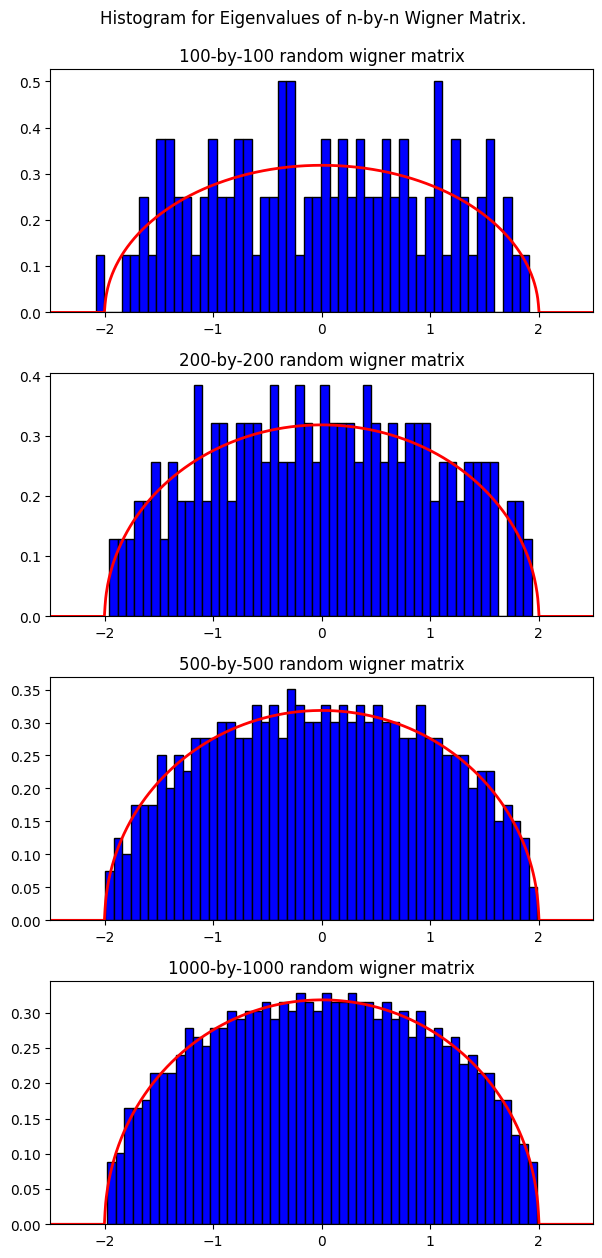

In [7]:
x = np.linspace(-3, 3, 1000) # generates 1000 evenly spaced values from -3 to 3
y = list(map(lambda xi: wigner_density(xi), x)) # calculates the Wigner semicircle density for each value in x

arr = [100, 200, 500, 1000] # list of sizes (n) of Wigner matrix
wigner_matrix = list(map(lambda n: generate_wigner(n), arr)) # list of Wigner matrices of size n-by-n
wigner_eigenvalues = list(map(lambda Z: get_spectrum(Z), wigner_matrix)) # list of eigenvalues of Wigner matrices

wigner_plot(arr, wigner_eigenvalues, x , y)

**At least based on looking at the plots, how big does `n` have to be before the semicircular law appears to be a good fit? In practice, we would answer this question more rigorously with, for example, a Kolmogorov-Smirnov test, which you can find in the `scipy.stats` module, but that is entirely optional.**

**Note: this experiment involves some matrix eigenvalue computations, which are comparatively expensive. If you set n larger than about 5000, be prepared to wait a few minutes for your answer, especially if you are running on an older machine or on a VM.**

Looking at the above example, a 500-by-500 Wigner matrix eigenvalues do seem to fit sufficiently well with the semicircular law. That said, for a $n > 500$, the corresponding n-by-n Wigner Matrix smoothens out the edges and gives us a very good approximation of the semicircular law, as can be witnessed in the 1000-by-1000 Wigner matrix. However, given the time it takes to run it, I believe a 500-by-500 should be sufficient.

Below is a plot to show what a 10000-by-10000 Wigner eigenvalues overlayed with wigner density looks like for reference.

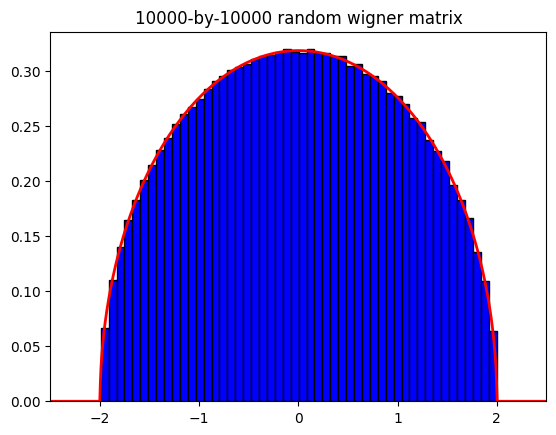

In [8]:
x = np.linspace(-3, 3, 1000) # generates 1000 evenly spaced values from -3 to 3
y = list(map(lambda xi: wigner_density(xi), x)) # calculates the Wigner semicircle density for each value in x

n = 10000 # size of Wigner matrix
wigner_eigenvalue = get_spectrum( generate_wigner(n) ) # eigenvalues of n-by-n Wigner matrix

plt.hist(wigner_eigenvalue, # histogram of eigenvalues of Wigner matrix
         density = True, # normalizes the histogram
         bins = 50, # sets the number of bins to 50
         color = 'blue', # sets the color of the histogram to blue
         edgecolor = 'black', # sets the color of the edges of the bars to black
         alpha = 1) # ``

plt.plot(x, # input for the Wigner semicircle density
         y, # output for the Wigner semicircle density
         color = 'red', # sets the color of the line to red
         linewidth = 2) # sets the width of the line to 2
      
# sets the title, x-axis label, y-axis label, and x-axis limits
plt.xlim([-2.5, 2.5])
plt.title(f'{n}-by-{n} random wigner matrix')

plt.show()

## 2.) Plotting a Mixture of Normals (3 points, spent $\approx$ 20 minutes)

**The whole reason that we use plotting software is to visualize the data that we are working with, so let’s do that. The zip file located at https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/hw/hw6_files.zip contains two files, storing data from a simulation experiment in my own research. The file `points.dlm` is a tab-delimited file (.dlm stands for “delimited”). Such a format is common when writing reasonably small files, and is useful if you expect to use a data set across different programs or platforms.**

**See the documentation for the command `numpy.loadtxt` to see how to read this file. The file `labels.npy` is a `numpy` binary file, representing a `numpy` object. The `.npy` file format is specific to `numpy`. Many languages (e.g., R and MATLAB) have their own such language-specific file formats for saving variables, workspaces, etc. These formats tend to be more space-efficient, typically at the cost of program-dependence. It is best to avoid such files if you expect to deal with the same data set in several different environments (e.g., you run experiments in MATLAB and do your statistical analysis in R). `.npy` files are opened using `numpy.load`.**

**The observations in my experiment were generated from a distribution that is *approximately* a mixture of normals, but not precisely so. Let’s explore how well the normal approximation holds.**

**Download the .zip file, extract it, and read the two files into `numpy`. Please include both `labels.npy` and `points.dlm` in your final submission. The former of these should yield a `numpy` array of 0s and 1s, and the latter should yield a 100-by-2 `numpy` array, in which each row corresponds to a 2-dimensional point. Each of these 2-dimensional points is assigned to one of two clusters. The i-th entry of the array in `labels.npy` encodes this the cluster membership label of the point in the i-th row of the matrix stored in `points.dlm`.**

In [9]:
labels = np.load('labels.npy') # loads the labels.npy file
points = np.loadtxt('points.dlm') # loads the points.dlm file
print(f'labels.shape = {labels.shape}')
print(f'points.shape = {points.shape}')

labels.shape = (100,)
points.shape = (100, 2)


**Generate a scatter plot of the data. Each data point should appear as an x (often called a cross in data visualization packages), colored according to its cluster membership as given by `points.npy`. The points with cluster label 0 should be colored blue, and those with cluster label 1 should be colored red. Set the x- and y- axes to both range from 0 to 1. Adjust the size of the point markers to what you believe to be reasonable (i.e., aesthetically pleasing, visible, etc.).**

In [10]:
def split_by_label(points, labels):
    '''
    function to split points by label 0 and 1

    inputs
    points : numpy.ndarray
             the points to be split
    
    labels : numpy.ndarray
             the labels to be used for splitting

    outputs
    zero_label_points : numpy.ndarray
                        the points with label 0
    
    one_label_points : numpy.ndarray
                       the points with label 1
    '''

    zero_label_points = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)
    one_label_points = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)

    for i in range(len(points)):
        if labels[i] == 0:
            zero_label_points = np.vstack(( zero_label_points, points[i] )) # adds the point to zero_label_points
        else:
            one_label_points = np.vstack(( one_label_points, points[i] )) # adds the point to one_label_points

    return zero_label_points, one_label_points

zero_label_points, one_label_points = split_by_label(points, labels)
print(f'zero_label_points.shape = {zero_label_points.shape}')
print(f'one_label_points.shape = {one_label_points.shape}')

zero_label_points.shape = (41, 2)
one_label_points.shape = (59, 2)


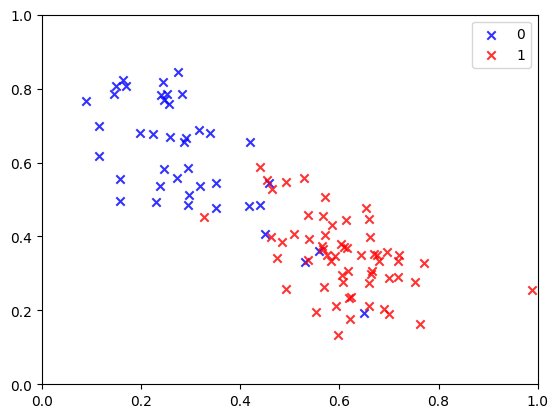

In [11]:
def scatter_plot():
    '''
    function to create a scatter plot of the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot

    axs : matplotlib.axes._subplots.AxesSubplot
          the axes object for the scatter plot
    '''
    fig, axs = plt.subplots()

    axs.scatter(zero_label_points[:, 0], # x values for label 0
               zero_label_points[:, 1], # y values for label 0
               marker = 'x', # sets the marker to 'x'
               alpha = 0.8, # sets the opacity to 0.8
               color = 'blue', # sets the color to blue
               label = '0') # sets the label to 0

    axs.scatter(one_label_points[:, 0], # x values for label 1
                one_label_points[:, 1], # y values for label 1
                marker = 'x', # sets the marker to 'x'
                alpha = 0.8, # sets the opacity to 0.8
                color = 'red', # sets the color to red
                label = '1') # sets the label to 1

    axs.legend(loc = 'upper right') # sets the location of the legend to upper right

    axs.set_xlim(0, 1) # sets the x-axis limits to 0 and 1
    axs.set_ylim(0, 1) # sets the y-axis limits to 0 and 1

    return fig, axs

fig, ax = scatter_plot()
plt.show()

**Theoretically, the data should approximate a mixture of normals with means and covariance matrices given by**

$$ \mu_0 = (0.2, 0.7)^T, \quad \sum_0 = 
\begin{pmatrix} 
0.015 & -0.011\\
-0.011 & 0.018
\end{pmatrix} $$

$$ \mu_1 = (0.65, 0.3)^T, \quad \sum_1 = 
\begin{pmatrix} 
0.016 & -0.011\\
-0.011 & 0.016
\end{pmatrix} $$

**For each of these two normal distributions, add two contour lines corresponding to 1 and 2 “standard deviations” of the distribution. We will take the 1-standard deviation contour to be the level set (which is an ellipse) of the normal distribution that encloses probability mass 0.68 of the distribution, and the 2-standard deviation contour to be the level set that encloses probability mass 0.95 of the distribution.** 

**The contour lines for cluster 0 should be colored blue, and the lines for cluster 1 should be colored red. The contour lines might go off the edge of the 1-by-1 square that we have plotted. Do not worry about that.**

**Hint: these ellipses are really just confidence regions given by**

$$ (x - \mu)^T \sum^{-1} (x - \mu) \le \chi^2_2(p)$$

**where p is a probability and $\chi^2_d$ is the quantile function for the $\chi^2$ distribution with $d$ degrees of freedom.** 

**Hint: use the optional argument `levels` for the `pyplot.contour` function. The quantile function for the $\chi^2$ distribution is available in `scipy.stats.chi2`.**

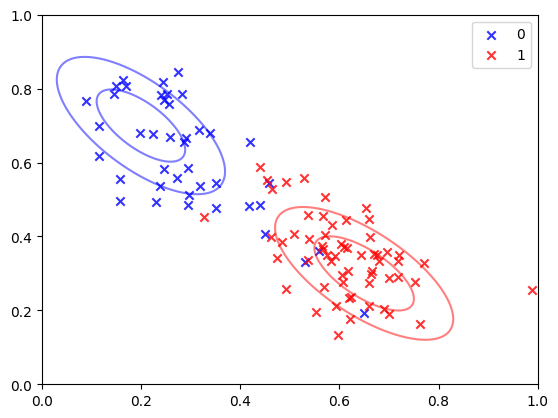

In [12]:
# multivariate_normal is a class scipy.stats
# documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html

mu_0 = np.array([0.2, 0.7]) # mean of the multivariate normal distribution for 0 label
cov_0 = np.array([[0.015, -0.011], [-0.011, 0.018]]) # covariance matrix of the multivariate normal distribution for 0 label
rv_0 = multivariate_normal(mu_0, cov_0) # multivariate random variable for 0 label

mu_1 = np.array([0.65, 0.3]) # mean of the multivariate normal distribution for 1 label
cov_1 = np.array([[0.016, -0.011], [-0.011, 0.016]]) # covariance matrix of the multivariate normal distribution for 1 label
rv_1 = multivariate_normal(mu_1, cov_1) # multivariate random variable for 1 label

x = np.linspace(0, 1, 1000) # generates 1000 evenly spaced values from 0 to 1
y = np.linspace(0, 1, 1000) # generates 1000 evenly spaced values from 0 to 1
X, Y = np.meshgrid(x, y) # creates a rectangular grid out of an array of x values and an array of y values
pos = np.dstack((X, Y)) # stacks the x and y values together

def contour_plot():
    '''
    function to create a contour plot of the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot + contour plot

    axs : matplotlib.axes._subplots.AxesSubplot
         the axes object for the scatter plot + contour plot
    '''
    fig, axs = scatter_plot()

    axs.contour(x, # x values for the contour plot
                y, # y values for the contour plot
                rv_0.pdf(pos), # multivariate normal probability density function for 0 label
                alpha = 0.5, # sets the opacity to 0.5             
                colors = 'blue',
                levels = 2) # sets the color to blue
    
    axs.contour(x, # x values for the contour plot
                y, # y values for the contour plot
                rv_1.pdf(pos), # multivariate normal probability density function for 1 label
                alpha  = 0.5, # sets the opacity to 0.5
                colors = 'red',
                levels = 2) # sets the color to red

    return fig, axs

fig, ax = contour_plot()
plt.show()

**Do the data appear normal? There should be at least one obvious outlier. Add an annotation to your figure indicating one or more such outlier(s).** 

**Note: as with many things in statistics, what does or does not constitute an outlier is ultimately a judgment call. There is not, strictly speaking, a right or wrong answer to this. Simply annotate your figure to indicate which points appear to you to be outliers**

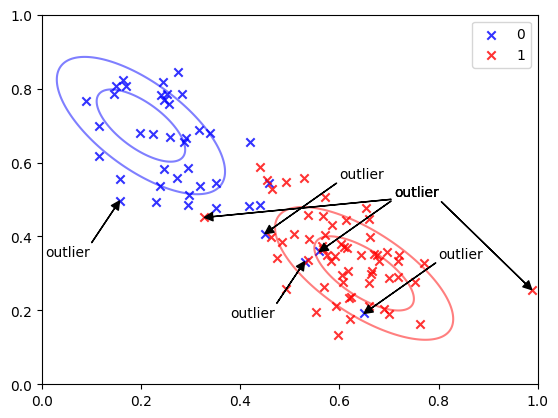

In [13]:
def detect_outlier(points, distribution, tolerance):
    '''
    function to detect outliers in the points

    inputs
    points : numpy.ndarray
             the points to be checked for outliers
    
    distribution : scipy.stats._multivariate.multivariate_normal_frozen object
                   the distribution to be used for checking

    tolerance : int or float
                the tolerance level for the distribution
    '''
    outliers = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)

    for point in points:
        # appends the point to outliers if the pdf of the distribution at the point is less than the tolerance
        # note: tolerance of 1.0 was chosen after some trial and error
        if (distribution.pdf(point) < tolerance):
            outliers = np.vstack(( outliers, point )) # adds the point to outliers
    return outliers

def annotate_outliers():
    '''
    function to annotate the outliers in the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot + contour plot + annotated outliers

    axs : matplotlib.axes._subplots.AxesSubplot
          the axes object for the scatter plot + contour plot + annotated outliers
    '''

    fig, axs = contour_plot()

    zero_label_outlier = detect_outlier(zero_label_points, rv_0, tolerance = 1.0) # detects outliers for 0 label
    one_label_outlier = detect_outlier(one_label_points, rv_1, tolerance = 1.0) # detects outliers for 1 label

    # documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html
    # example for arrow: https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotation_polar.html#sphx-glr-gallery-text-labels-and-annotations-annotation-polar-py
    arrow_features = dict(facecolor = 'black', # color of the arrow
                          width = 0.1, # width of the arrow
                          headwidth = 6, # width of the head of the arrow
                          headlength = 6) # length of the head of the arrow
    
    dist_arrow = 0.15 # distance of the arrow annotation from the point

    for idx, zero_outlier in enumerate(zero_label_outlier):
        if idx % 2 == 0: # alternates the position of the arrow annotation, to avoid the annotations from overlapping
            axs.annotate('outlier', # text for the annotation
                        xy = (zero_outlier[0], zero_outlier[1]), # the point to be annotated
                        xytext = (zero_outlier[0] + dist_arrow, zero_outlier[1] + dist_arrow), # arrow anotates from the point to the right and above
                        arrowprops = arrow_features)
        else:
            axs.annotate('outlier', # text for the annotation
                        xy = (zero_outlier[0], zero_outlier[1]), # the point to be annotated
                        xytext = (zero_outlier[0] - dist_arrow, zero_outlier[1] - dist_arrow), # arrow anotates from the point to the left and below
                        arrowprops = arrow_features)

    # no need for alternating position for the arrow annotation as there are much fewer outliers
    for one_outlier in one_label_outlier:
        axs.annotate('outlier', # text for the annotation
                    xy = (one_outlier[0], one_outlier[1]), # the point to be annotated
                    xytext = (zero_outlier[0] + dist_arrow, zero_outlier[1] + dist_arrow), # arrow anotates from the point to the right and above
                    arrowprops = arrow_features)

    return fig, axs

fig, ax = annotate_outliers()
plt.show()

Except for a couple of outliers (annotated above), the data appear to be sufficiently normal as most of the blue and red points lie within the contour pdfs of the multivariate normal distribution defined above.

## 3.) Conway's Game of Life (4 points, spent $\approx$ 35 minutes)

**Conway’s Game of Life is a classic example of a cellular automaton devised by mathematician John Conway. The game is a classic example of how simple rules can give rise to complex behavior. The game is played on an $m$-by-$n$ board, which we will represent as an $m$-by-$n$ matrix. The game proceeds in steps. At any given time, each cell of the board (i.e., entry of our matrix), is either alive (which we will represent by the Boolean `True`) or dead (which we will represent by the Boolean `False`). At each step, the board evolves according to a few simple rules:**

* **A live cell with fewer than two live neighbors becomes a dead cell.**

* **A live cell with more than three live neighbors becomes a dead cell.**

* **A live cell with two or three live neighbors remains alive.**

* **A dead cell with exactly three live neighbors becomes alive.**

* **All other dead cells remain dead.**

**The neighbors of a cell are the $8$ cells adjacent to it, i.e., left, right, above, below, upper left, lower-left, upper-right and lower-right. We will follow the convention that the board is toroidal, so that using matrix-like notation (i.e., the cell $(0,0)$ is in the upper-left of the board and the first coordinate specifies a row), the upper neighbor of the cell $(0,0)$ is $(m − 1,0)$, the right neighbor of the cell $(m − 1,n − 1)$ is $(m − 1,0)$, etc. That is, the board “wraps around”. This definition gets a bit odd when the board is smaller then three-by-three. You may simply ignore that case in what follows, if you wish. It will not be included when testing your code.**
 
**Note: you are not required to use this matrix-like indexing. It’s just what I chose to use to explain the toroidal property.**

**Write a function `is_valid_board` that takes a single argument and returns a Python Boolean that is `True` if and only if the argument is a valid representation of a Game of Life board. A valid board is any two-dimensional `numpy` `ndarray` whose entries are all numpy Booleans (i.e., `numpy.bool_`). Note that your function should accept, e.g., a two-by-two board as valid, even if the definition for generating the next step in such a board is a bit odd**

In [14]:
def is_valid_board(board):
    '''
    function to check if a given board is valid

    inputs
    board : numpy.ndarray
            the board (matrix) to be checked

    outputs
    True : bool
           if the board is valid, i.e., all elements are either False/True
    
    False : bool
            if the board is not valid, i.e., at least one element is not either False/True
    '''
    if not board.shape[0] > 1:
        raise ValueError(f'Matrix must have at least 1 row.') # raises error when the matrix does not have at least 1 row.
    
    if not board.shape[1] > 1:
        raise ValueError(f'Matrix must have at least 1 column.') # raises error when the matrix does not have at least 1 column.

    return np.issubdtype(board.dtype, np.bool_) # returns True if all elements of M are either False/True or 0/1, otherwise returns False

# testing the function with a 6-by-6 Beacon (period 2)
# https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life
beacon = np.array([[False,False,False,False,False,False], 
                   [False,True,True,False,False,False], 
                   [False,True,True,False,False,False], 
                   [False,False,False,True,True,False],
                   [False,False,False,True,True,False],
                   [False,False,False,False,False,False]]).reshape(6, 6)

print(is_valid_board(beacon)) # True    

True


**Write a function called `gol_step` that takes an $m$-by-$n$ `numpy` array as its argument and returns another `numpy` array of the same size (i.e., also $m$-by-$n$), corresponding to the board at the next step of the game. Your function should perform error checking to ensure that the provided argument is a valid Game of Life board.**

In [15]:
def neighbors(i, j, rows, cols):
    '''
    function to get the eight surrounding neighbors of any given cell

    inputs
    i : int
        the row index of the cell

    j : int
        the column index of the cell

    rows : int
           the number of rows in the board (M.shape[0])

    cols : int
           the number of columns in the board (M.shape[1])  

    outputs
    neighbors : list
                the list of neighbors (left, right, upper, lower, upper_right, lower_right, upper_left, lower_left) of the cell
    '''

    left = (i, (j - 1) % cols) # cycles a column left, and wraps around to the last column if the column is 0
    right = (i, (j + 1) % cols) # cycles a column right, and wraps around to the first column if the column is the last column
    upper = ((i - 1) % rows, j) # cycles a row up, and wraps around to the last row if the row is 0
    lower = ((i + 1) % rows, j) # cycles a row down, and wraps around to the first row if the row is the last row
    upper_right = ((i - 1) % rows, (j + 1) % cols) # cycles a row up and a column right (as in upper and right)
    upper_left = ((i - 1) % rows, (j - 1) % cols) # cycles a row up and a column left (as in upper and left)
    lower_right = ((i + 1) % rows, (j + 1) % cols) # cycles a row down and a column right (as in lower and right)
    lower_left = ((i + 1) % rows, (j - 1) % cols) # cycles a row down and a column left (as in lower and left)

    neighbors = [left, right, upper, lower, upper_right, lower_right, upper_left, lower_left]
    return neighbors

def gol_step(M):
    '''
    function to perform one single step of the Conway's Game of Life

    inputs
    M : numpy.ndarray
        the board to be updated

    outputs
    temp : numpy.ndarray
           the updated board after one step of the Conway's Game of Life
    '''
    if not is_valid_board(M):
        raise ValueError(f'Matrix must contain only boolean entries (1/0 or True/False).')
    
    rows = M.shape[0] # number of rows in the board
    cols = M.shape[1] # number of columns in the board
    
    temp = M.copy() # creates a copy of the board
    for i in range(rows): # cycles through the rows of the board
        for j in range(cols): # cycles through the columns of the board

            # sums the number of live neighbors of the cell
            # uses the function neighbors() to get the eight surrounding neighbors of the cell
            tot_live = sum( M[neighbor] for neighbor in neighbors(i, j, rows, cols) )

            if M[i, j] == True and (tot_live < 2 or tot_live > 3): # cell dies if it is alive and has less than 2 or more than 3 live neighbors
                temp[i, j] = False
            # else if cell is alive and has 2 or 3 live neighbors, it remains alive
                
            elif M[i, j] == False and (tot_live == 3): # cell becomes alive if it is dead and has exactly 3 live neighbors
                temp[i, j] = True
            # else if cell is dead and has less than 3 or more than 3 live neighbors, it remains dead
                
    return temp

# for the following, we expect only cell (3, 3) and (4, 4) to keep oscillating between True and False
# and the rest of the cells to remain False
beacon_1 = gol_step(beacon)
beacon_2 = gol_step(beacon_1)
beacon_3 = gol_step(beacon_2)

print('step 0:\n', beacon)
print('\nstep 1:\n', beacon_1)
print('\nstep 2:\n', beacon_2)

step 0:
 [[False False False False False False]
 [False  True  True False False False]
 [False  True  True False False False]
 [False False False  True  True False]
 [False False False  True  True False]
 [False False False False False False]]

step 1:
 [[False False False False False False]
 [False  True  True False False False]
 [False  True False False False False]
 [False False False False  True False]
 [False False False  True  True False]
 [False False False False False False]]

step 2:
 [[False False False False False False]
 [False  True  True False False False]
 [False  True  True False False False]
 [False False False  True  True False]
 [False False False  True  True False]
 [False False False False False False]]


**Write a function called `draw_gol_board` that takes an $m$-by-$n$ numpy array (i.e., an ndarray) as its only argument and draws the board as an $m$-by-$n$ set of tiles, colored black or white correspond to whether the corresponding cell is alive or dead, respectively. Your plot should not have any grid lines, nor should it have any axis labels or axis ticks.** 

**Hint: see the functions `plt.xticks()` and `plt.yticks()` for changing axis ticks.**

**Hint: you may find the function `plt.get_cmap` to be useful for working with the `matplotlib` `Colormap` objects.**

(<Figure size 640x480 with 1 Axes>, <Axes: >)

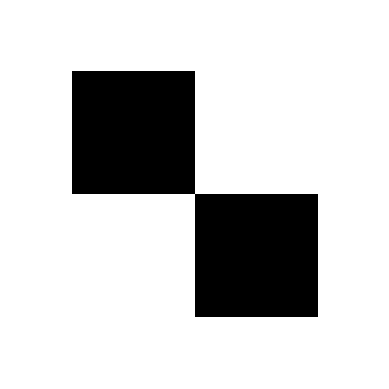

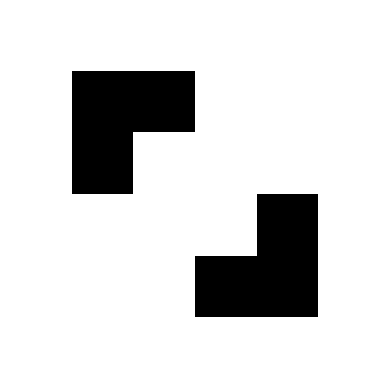

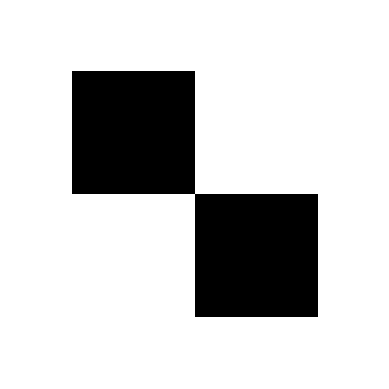

In [16]:
def draw_gol_board(M):
    '''
    function to draw the Conway's Game of Life board

    inputs
    M : numpy.ndarray
        the board to be drawn

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the Conway's Game of Life board

    ax : matplotlib.axes._subplots.AxesSubplot
         the axes object for the Conway's Game of Life board
    '''

    if not is_valid_board(M):
        raise ValueError(f'Matrix must contain only boolean entries (1/0 or True/False).')
    
    fig, ax = plt.subplots()
    ax.axis('off')
    
    # draws the board using a grayscale colormap 
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.matshow.html   
    ax.matshow(M, cmap = 'gray_r')
    
    return fig, ax

# just like above, we expect only cell (3, 3) and (4, 4) to change from black to white and vice versa
draw_gol_board(beacon)
draw_gol_board(beacon_1)
draw_gol_board(beacon_2)

**Create a $20$-by-$20$ numpy array corresponding to a Game of Life board in which all cells are dead, with the exception that the top-left $5$-by-$5$ section of the board looks like as follows:**

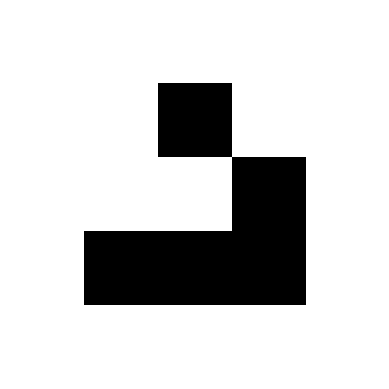

In [17]:
glider = np.array([[False,False,False,False,False],
                   [False,False,True,False,False],
                   [False,False,False,True,False],
                   [False,True,True,True,False],
                   [False,False,False,False,False]])
draw_gol_board(glider)
plt.show()

**Plot this $20$-by-$20$ board using `draw_gol_board`, save this plot in `.png` file called `glider_board.png`, and include it in your submission.**

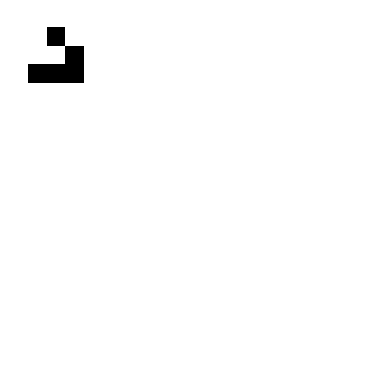

In [18]:
big_glider = np.full((20, 20), False) # creates a 20-by-20 board of False

for i in range(glider.shape[0]): # cycles through the rows of the board
    for j in range(glider.shape[1]): # cycles through the columns of the board
        big_glider[i, j] = glider[i, j] # sets the values of the smaller board to the larger board, leaves the rest as zeros

draw_gol_board(big_glider)
plt.show()

**Generate a plot with 5 subplots, arranged in a $5$-by-$1$ grid, showing the first five steps of the Game of Life when started with the board you just created, with the steps ordered from top to bottom. The first plot should be the starting board just described, so that the starting board is the first “step”. The figure in the $5$-by-$5$ sub-board above is called a glider, and it is interesting in that, as you can see from your plot, it seems to move along the board as you run the game. Save the resulting plot in a `.png` file called `glider_5steps.png`, and include it in your submission.**

In [19]:
def game_of_life_plot(n, initial_gol):
    '''
    function to plot the histogram of eigenvalues of Wigner matrix

    inputs
    n : int
        subplots and steps to take in the game of life board.

    initial_gol : numpy.ndarray
                  the initial board for the game of life

    outputs
    fig : matplotlib.figure.Figure
          the figure object for first n steps of gol board
    '''

    if not is_valid_board(initial_gol):
        raise ValueError(f'Matrix must contain only boolean entries (1/0 or True/False).')
    
    steps = [initial_gol] # list to store the steps of the game of life board,
    for i in range(1, n):
        curr = steps[i-1] # gets the current step of the game of life board
        step = gol_step(curr) # gets the next step of the game of life board
        steps.append(step) # adds the next step to the list of steps

    fig, axs = plt.subplots(n, figsize = (15, 15))

    for i in range(n):
        axs[i].matshow(steps[i], cmap = 'gray_r') # draws the game of life board
        axs[i].axis('off')
    
    return fig, axs

(<Figure size 1500x1500 with 5 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

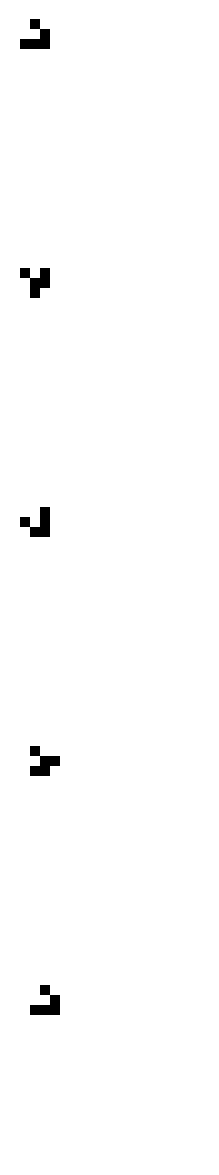

In [20]:
game_of_life_plot(5, big_glider)

***Optional additional exercise:* create a function that takes two arguments, a Game of Life board and a number of steps, and generates an animation of the game as it runs for the given number of steps. Note: this is an optional exercise. It is not worth any points, and does not count for any bonus points.**

In [21]:
import imageio.v2 as imageio # library used to create gif, installed using `pip install imageio`
import os # library used to interact with the operating system

def gif_gol(initial_gol, n):
    '''
    function to create a gif of the game of life board

    inputs
    initial_board : numpy.ndarray
                    the initial board for the game of life

    n : int
        the number of steps to take in the game of life board

    outputs
    '''

    if not is_valid_board(initial_gol):
        raise ValueError(f'Matrix must contain only boolean entries (1/0 or True/False).')

    if not os.path.exists('frames_gol'):
        os.makedirs('frames_gol') # creates a directory to store the frames of the game of life board

    steps = [initial_gol] # list to store the steps of the game of life board
    for i in range(1, n):
        curr = steps[i - 1] # gets the current step of the game of life board
        step = gol_step(curr) # gets the next step of the game of life board
        steps.append(step) # adds the next step to the list of steps
    
    for i in range(n):
        fig, ax = plt.subplots()
        ax.matshow(steps[i], cmap = 'gray_r') # draws the game of life board
        ax.axis('off')
        plt.savefig(f'frames_gol/step_{i}.png') # stores the frame of the game of life board in the directory frames_gol
        plt.close()

    with imageio.get_writer('gol.gif', mode = 'I') as writer:
        for i in range(n):
            image = imageio.imread(f'frames_gol/step_{i}.png') # reads each frame of the game of life board from the directory frames_gol
            writer.append_data(image) # appends the frame to the gif

    for i in range(n):
        os.remove(f'frames_gol/step_{i}.png') # deletes each frame of the game of life board from the directory frames_gol
        
    os.rmdir('frames_gol') # deletes the entire directory frames_gol

gif_gol(big_glider, 100) # creates a gif of the game of life board

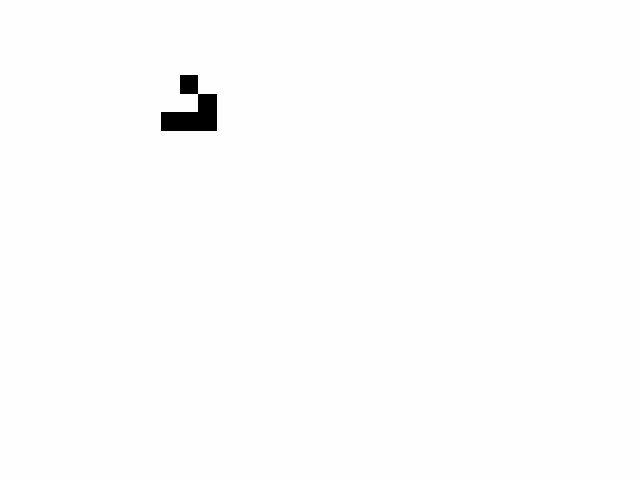

In [22]:
from IPython.core.display import Image 
Image(filename = 'gol.gif') # used to display the gif in the notebook

# uncomment the following line of code if you wish to delete this gif from directory
# os.remove('gol.gif') # removes the gif file if required